(sec:openqm-qme-method)=
# Optical quantum master equations

## Full Hamiltonian

In order to investigate the optical properties of emitters, we need a Hamiltonian consisting of three parts, $H_{S}$ for the system of emitters, $H_{R}$ for the radiation field, and $H_{SR} for the coupling between them.  They are already introduced in {numref}`sec:emitter`, {numref}`sec:radiation-field`}, and {numref}`sec:E1-coupling`.

Formally, we are supposed to solve the Liouville-von Neumann equation $\rho_{SR} = -i \left[H_{S}+H_{R}+H_{SR},\rho_{SR}\right]$ but it is mathematically quite demanding.  Hence, we need some approximations.   

There are two effects of the interaction with the radiation field on the emitters.  One is the energy shift including the Lamb shift and the dipole-dipole coupling, which is the real part of the self energy.    The other is the dissipation which arises from the imaginary part of the self energy.  The result of the approximation is given below.

## Quantum master equation: A general form

If the interaction between the system and the radiation field is weak, we can use the perturbation theory (the Born approximation).  We also assume the radiation field goes back to the thermal equilibrium instantly after a photon is emitted. (Markovian approximation).  Furthermore, we adopt the rotating wave approximation  With these approximation, we can calculate the evolution of the emitters and the radiation field separately. For the emitters, the evolution of the reduced density $\rho_{S}$ is determined by the quantum master equation, which is also known as the Lindblad equation $\frac{d}{dt}\rho_{S} = \mathcal{L} (\rho_{S})$ where $\mathcal{L}$ is the Lindbladian superoperator which consists of two parts, a unitary part (also called coherent part) and dissipator:

$$
\mathcal{L} (\rho_{S}) = -i [H_{S}+H^\prime_{S}, \rho_{S}] + \mathcal{D} (\rho_{S})
$$(eq:qme-general)

The first term in the right hand side is the unitary part, which includes additional Hamiltonian $H^\prime_{S}$.   The second term is the dissipator expressed as a super operator which takes a general form:

$$
\mathcal{D} (\rho) = \gamma \left[L \rho L^\dagger - \frac{1}{2} \left\{L^\dagger L, \rho\right\} \right]
$$(eq:dissipator-general)

where the anticommutator $\{A,B\} = AB + BA$ is used.  The operator $L$ is known by various names, a Lindblad operator, a jump operator, or a collapse operator and $\gamma$ is the rate of dissipation. (We shall call it collapse operator in this lecture.)   There can be several different dissipators in a single quantum master equation.

WE have dropped index $S$ in the density operator.  Hereafter, $\rho$ is the reduced density operator for the emitters unless otherwise is stated.

## Optical master equation

Using the Hamiltonian for the whole system $H=H_{S}+H_{R}+H_{SR}$, we obtain the quantum master equation for the emitters coupled to the radiation field as

$$
\frac{d}{dt} \rho = -i [H_{S} + H_\text{Lamb} + H_{dd},\rho] + \mathcal{D} (\rho)
$$

with the Lamb shift $H_\text{Lamb}$ and the dipole-dipole interaction

$$
H_\text{dd} = \sum_{i \ne j} \Omega_{ij} \sigma^{+}_{i}\sigma^{-}_{j}.
$$(eq:H_dd)

The Lamb shift diverges in the non-relativistic quantum mechanics. The renormalization of electron mass and charge in QFT resolves this issue. It turns out that the shift is very small. We shall ignore it.

The microscopic derivation of the quantum master equation finds the following dissipator:

$$
\begin{aligned}
\mathcal{D}(\rho) &= \sum_{i,j} \Gamma_{ij}\, (N_T+1) \left[\sigma^{-}_{j} \rho \sigma^{+}_{i} - \frac{1}{2}\left\{\sigma^{+}_{i}\sigma^{-}_{j}, \rho\right\} \right] \\
&+ \sum_{i,j}\Gamma_{ij}\, N_T \left[\sigma^{+}_{j} \rho \sigma^{-}_{i} - \frac{1}{2}\left\{\sigma^{-}_{i}\sigma^{+}_{j}, \rho\right\} \right]
\end{aligned}
$$(eq:optical-dissipator)

where $N_T = \frac{1}{e^{\omega_0/T - 1}}$ is the mean thermal photon number at temperature $T$.  The first term in the right hand side corresponds to the emission and the second term to the absorption.

## Dipole-diploe coupling

The coefficient of the H$_{dd}$ {eq}`eq:H_dd` is given by

$$
\Omega_{i\ne j} = - \frac{3\gamma_0}{4} \left[ \left(1 - \cos^2 \theta_{ij}\right) \frac{\cos(k_0 r_{ij})}{k_0 r_{ij}}
+ \left(1-3 \cos^2 \theta_{ij} \right) \left (\frac{\sin(k_0 r_{ij})}{(k_0 r_{ij})^2} -  \frac{\cos(k_0 r_{ij})}{(k_0 r_{ij})^3} \right) \right]
$$(eq:omega_ij)

where $\theta_{ij}$ is the angle betwen $\mathbf{d}$ and $\mathbf{r}_{ij}$ and the rate of spontaneous emission is defined by  

$$
\gamma^{0} = \frac{4 \omega_{0}^{3} |\vec{d}|^2}{3\hbar c^3}.
$$ 

$\Omega_{ij}$ diverges as $r_{ij} \rightarrow 0$ by the same as the dirvergence of the Lamb shift.   We cannot the dipole-dipole interaction when the two emitters are too close.

The main role of this coupling is to shift the energy eigenvalue of the emitters.  Without the $H_{dd}$, the spectra of $H_{S}$ is
$E_{ee}=\omega_0$, $E_{eg}=E_{ge}=0$, and $E_{gg}=-\omega_0$, and the corresponding eigenvectors are just the product basis kets.  When $H_{dd}$ is added.  $E_{ee}$ and $E_{gg}$ remain the same.  $E_{eg}$ and $E{ge}$ split to $E_{s} = \Omega_{12}$ and $E_{a} = - \Omega_{12}$.  The corresponding eigenstates are $|s\rangle = (|eg\rangle + |ge\rangle)/\sqrt{2}$ and $|a\rangle = (|eg\rangle - |ge\rangle)/\sqrt{2}$. From the perspective of the emitters, these eigenstates forms a more convenient basis than the product basis.

The following code plots the strength of the dipole-dipole coupling.  It is smaller than $\gamma_0$ except for $r_{12} \ll \lambda_{0}$. Hence, it does not play a significant role in realistic applications.

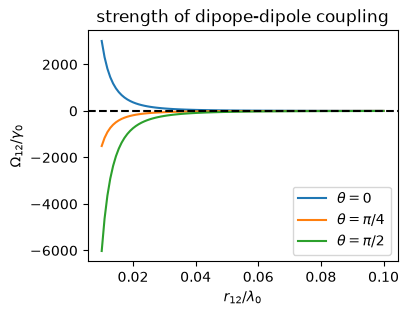

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,theta):
    y=(1-np.cos(theta)**2)*np.cos(x)/x + (1-3*np.sin(theta)**2)*(np.sin(x)/x**2 - np.cos(x)/x**3)
    return -y*3/4

x0=np.linspace(0.01,0.1,100)
x1=2*np.pi*x0
y1 = f(x1,0)
y2 = f(x1,np.pi/4)
y3 = f(x1,np.pi/2)
plt.figure(figsize=(4,3))
plt.title("strength of dipope-dipole coupling")
plt.plot(x0,y1,label=r"$\theta=0$")
plt.plot(x0,y2,label=r"$\theta=\pi/4$")
plt.plot(x0,y3,label=r"$\theta=\pi/2$")
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel(r"$\Omega_{12}/\gamma_{0}$")
plt.axhline(y=0, color='k', linestyle='--')
plt.legend(loc=4)
plt.show()

There is a big problem with the above formula. As the separation of two emitters vanishes, $\Omega_{12}$ diverges.  Equation {eq}`$$(eq:omega_ij` is derived under the assumption that the emitter is a point particle, which causes the divergence.  Using a finite size of radius $a$, the following formula avoid the divergence near $r_{12} \sim 0$:

$$
\Omega_{i\ne j}(\vec{r}) = \frac{3\gamma_{0}}{4} \left(1-3 \cos^2 \theta_{ij}  \right) \left(\frac{1}{r_{ij}k_{0}} \right)^3 \left[\text{erf}\left(\frac{r_{ij}}{\sqrt{2} a }\right) - \sqrt{\frac{2}{\pi}} \frac{ r_{ij}}{a} e^{-\frac{r_{ij}^2}{2a^2}} \right]
$$

## Decay rates

The diagonal coefficients in the dissipator {eq}`eq:optical-dissipator` are simply $\Gamma_{ii} = \gamma_{0}$ and the off-diagonal coefficients are defined by

$$
\Gamma_{i\ne j} & =  \frac{3\gamma_0}{2} \left[ \left(1 - \cos^2 \theta_{ij}\right) \frac{\cos(k_0 r_{ij})}{k_0 r_{ij}}
+ \left(1-3 \cos^2 \theta_{ij} \right) \left (\frac{\sin(k_0 r_{ij})}{(k_0 r_{ij})^2} -  \frac{\cos(k_0 r_{ij})}{(k_0 r_{ij})^2} \right) \right]
$$(eq:Gamma_ij)


The following code plots $\Gamma_{i\ne j}$ as the function of $r_{ij}/\lambda_{0}$, where $\lambda_{0} = 2\pi/k_{0} = 2 \pi c/\omega_0$.

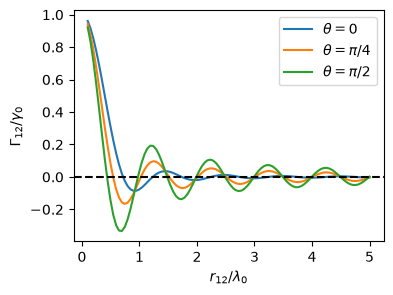

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,theta):
    y=(1-np.cos(theta)**2)*np.sin(x)/x + (1-3*np.cos(theta)**2)*(np.cos(x)/x**2 - np.sin(x)/x**3)
    return y*3/2

x0=np.linspace(0.1,5,100)
x1=2*np.pi*x0
y1 = f(x1,0)
y2 = f(x1,np.pi/4)
y3 = f(x1,np.pi/2)
plt.figure(figsize=(4,3))
plt.plot(x0,y1,label=r"$\theta=0$")
plt.plot(x0,y2,label=r"$\theta=\pi/4$")
plt.plot(x0,y3,label=r"$\theta=\pi/2$")
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel(r"$\Gamma_{12}/\gamma_{0}$")
plt.axhline(y=0, color='k', linestyle='--')
plt.legend(loc=1)
plt.show()

The above plot clearly shows that as $r_{ij} \rightarrow 0$, $\Gamma_{i\ne j} \rightarrow \gamma_0$, which indicates that when the radiation field cannot distinguish the emitters, all the coefficients are just $\gamma_0$.  On the other hand, if $r_{ij} \gg \lambda_0$, $\Gamma_{i\ne j} \ll 1$, which indicate that the cross correlation between the emitters $i$ and $j$ vanishes.  In conclusion, the indistinguishability of emitters by the radiation field is reflected in $\Gamma_{ij}$.

## Phonon scattering

Interaction with phonon may cause a significant impact on coherence for quantum dots. The quantum master equation acuires additional terms from the interaction Hamiltonian {eq}`eq:H_phi`.  First, there is a new dissipator

$$
\mathcal{D}^{\phi} (\rho) = - \sum_{ij} \Gamma^{\phi}_{ij} \left ( \sigma^{z}_{i} \rho \sigma^{z}_{j} - \frac{1}{2} \left\{\sigma^{z}_{j}\sigma^{z}_{i},\rho\right\} \right)
$$

which could play a significant role in decoherence.  We will see if this dissipation has some impact on coherency in applications.

Secondly, a new coupling Hamiltonian shows up:

$$
H_{\phi-\phi} = \sum_{i\ne j} \Gamma(\mathbf{x}_{i} - \mathbf{x}_{j}) \sigma^{z}_{i}\sigma^{z}_{j}
$$

with the coupling strength is given by

$$
\Gamma(\mathbf{x}) = \sum_{\mathbf{q}} \frac{2|g_\mathbf{q}|^2}{\omega_{\mathbf{q}}} \cos(\mathbf{q}\cdot\mathbf{x})
$$

where $\omega_\mathbf{q}$ is the energy of phonon with momentum $\mathbf{q}$.

Since this term commutes with $H_{0}$, no energy exchange is involved.  They expected to induce pure dephasing. 
However, it seems that the effect of dephasing is not significant in many applications since competing couplings such as quantum tunneling is stronger.

## Ambiguity

The expression of a quantum master equation is not unique.  It is invariant under many transformation.  Suppose that the dissipator is given by

$$
\mathcal{D}\rho = \sum_{j} \left(A_{j} \rho A^{\dagger}_{j} - \frac{1}{2} \left \{A^{\dagger}_{j}A_{j},\rho\right\}\right)
$$

Introducing a set of new operators using a unitary transformation $U$ such that $B_{j} = \sum_{k} U_{jk} A_{k}$, the dispator is transformed to

$$
\mathcal{D}\rho = \sum_{j} \left(B_{j} \rho B^{\dagger}_{j}- \frac{1}{2} \left \{B^{\dagger}_{j}B_{j},\rho\right\}\right)
$$

Even under a simple shift $B_{j} = A_{j} + \alpha_{j}$ where $\alpha_{j}$ is a constant, the dissipator is invariant.  Hence, there are infinitely many expression of the same quantum master equation.  


**Example**

Consider the following dissipator:

$$
\mathcal{D} \rho = \sum_{ij} \Gamma_{ij}  \left( \sigma^{+}_{j} \rho \sigma^{-}_{i} - \frac{1}{2} \left\{\sigma^{-}_{i}\sigma^{+}_{j}, \rho\right\} \right).
$$

We introduce introducing new operators:

$$
\eta^{\pm}_{1} = (\sigma^{\pm}_{1} + \sigma^{\pm}_{2})/\sqrt{2}, \qquad \eta^{\pm}_{2} = (\sigma^{\pm}_{1} - \sigma^{\pm}_{2})/\sqrt{2}
$$(eq:dissipator-sigma)

This transformation does not change $H_{S}$.  The original dissipator is transformed to 

$$
\mathcal{D} (\rho) = (\Gamma_{11}+\Gamma_{12}) \left( \eta^{+}_{1} \rho \eta^{-}_{1} - \frac{1}{2} \left\{\eta^{-}_{1}\eta^{+}_{1}, \rho\right\} \right) + (\Gamma_{11}-\Gamma_{12}) \left( \eta^{+}_{2} \rho \eta^{-}_{2} - \frac{1}{2} \left\{\eta^{-}_{2}\eta^{+}_{2}, \rho\right\} \right).
$$(eq:dissipator-eta)

Notice that there is no cross terms between $\eta^{\pm}_{1}$ and $\eta^{\mp}_{2}$.  We just diagonalized $\Gamma_{ij}$ and $\Gamma_{11}\pm \Gamma_{12}$ are the eigenvalues of the matrix.   An interesting situation arises when the distance between the two emitters is small. As $r_{12}$ vanishes, $\Gamma_{12} \rightarrow \Gamma_{11}$ and thus the second term in {eq}`eq:dissipator-eta` vanishes.  At the same time the decay rate of the first term is doubled.  This is the mechanism of superradiant which we discuss later.

The dissipator {eq}`eq:dissipator-eta` has a slight computational advantage.

Although the expression changed, the density operator is invariant under the transformation. So, if we are interested in only the state of the emitter, there seems no problem.  The expectation value of any observabale in the emitter's Hilbert space is indeed invariant. While mathematically the two dissipators {eq}`eq:dissipator-sgma` and {eq}`eq:dissipator-eta` are equivalent, they use different collapse operators, which has different physical interpretation.[^1] The collapse operator $\sigma^{-}_{j}$ describes the transition from $|e\rangle$ to $|g\rangle$ in the $j$-th emitter. On the other hand, $\eta^{-}_{j}$ represents collective deexcitation involving both emitters. Which one is better?  From the perspective of the emitters it does not matter.  However, the radiation field sees them differently.  When we trace out the radiation field to obtain the quantum master equation, the communication between the emitters and the radiation field is lost, which seems the origin of the ambiguity in the quantum master equation. We will find out more details when we discuss the perspective of the radiation field.


[^1]:The dissipator {eq}`eq:dissipator-eta` has a slight computational advantage, especially when `mesolve` in `QuTiP` is used.

## Detection of photons

In {numref}`ch:detector`, we learned the Glauber's theory of detection.  A history of clicks recorded by a detector corresponds to the measurement of radiation intensity.  However, a quantum master equation does not have that information.  Folloiwng Lehmberg {cite:p}`Lehmberg1970a`,  we can make a connection between the density matrix and intensity through the source radiation field  {eq}`eq:source_field_approx`.    The intensity at the position of detector $\mathbf{R}$ is given by

$$
I(\mathbf{x},t) = \langle E^{(-)}(\mathbf{x},t)E^{(+)}(\mathbf{x},t)\rangle \rangle =  
\langle J^{+}(\mathbf{R},t) J^{-}(\mathbf{R},t) \rangle
$$


where

$$
J^{\pm} (\mathbf{R},t) = \sqrt{\gamma(\mathbf{R})} \sum_{i} e^{ \pm i k_{0} \hat{\mathbf{R}} \cdot \mathbf{r}_{j}} \sigma^{\pm}_{j}(t).
$$(eq:jump-operator-R)

with the transition rate 

$$
\gamma(\mathbf{R}) = \left(\frac{\omega_{0}^{2}d}{c^2}\right)^{2} \left [ 1 - \left(\hat{\mathbf{d}}\cdot\hat{\mathbf{R}}\right)^2\right].
$$

This suggest that $J^{-}$ is the jump operator the detector measures (in the Heisenberg picture) if the all the emitters are coherent. 

If the emitters are not coherent,

$$
\begin{aligned}
I(\mathbf{x},t) &= \langle J^{+}(\mathbf{R},t) J^{-}(\mathbf{R},t) \rangle \\
&= \left(\frac{\omega_{0}^{2}d}{c^2}\right)^2 \left [ 1 - \left(\hat{\mathbf{d}}\cdot\hat{\mathbf{R}}\right)^2\right] \sum_{ij} e^{i k_0 \hat{\mathbf{R}}\cdot \mathbf{r}_{ij}} \langle \sigma^{+}_{i} \sigma^{-}_{j}\rangle \\
&= \left(\frac{\omega_{0}^{2}d}{c^2}\right)^2 \left [ 1 - \left(\hat{\mathbf{d}}\cdot\hat{\mathbf{R}}\right)^2\right] \sum_{j}  \langle \sigma^{+}_{j} \sigma^{-}_{j}\rangle 
\end{aligned}
$$

where we used the incoherent condition $\langle \sigma^{+}_{i} \sigma_{j}\rangle = 0$ for $i\ne j$.  In this case, $\sqrt{\gamma(\mathbf{R})} \sigma^{-}_{j}$ is the jump operator.  To convert this jump operator for the quantum master equation, we need to count all photons emitted in all direction.  Integrating $\gamma(\mathbf{R})$ over the solid angle

$$
\int_{0}^{2\pi} \int_{-\pi}^{\pi} \gamma(\mathbf{R}) \sin(\theta) d\theta d\phi = \gamma_0
$$

which is the standard rate of spontaneous emission.

## Coherence function

We now measure the second-order coherence function by a detector placed at $\mathbf{R}$.  Using the jump operators {eq}`eq:jump-operator-R`, 

$$
g^{(2)}(\tau;\mathbf{R}) 
= \frac{\langle J^{+}(\mathbf{R},t) J^{+}(\mathbf{R},t+\tau) J^{-}(\mathbf{R},t+\tau) J^{-}(\mathbf{R},t)  \rangle_{ss}}{(\langle J^{+}(\mathbf{R},t) J^{-}(\mathbf{R},t)\rangle_{ss})^2} =
= \frac{\sum_{ij} \sum_{k\ell} e^{i k_0 \hat{\mathbf{R}}\cdot \mathbf{r}_{ij}}e^{i k_0 \hat{\mathbf{R}}\cdot \mathbf{r}_{k\ell}} \langle\sigma^{+}_{i}(t) \sigma^{+}_{k}(t+\tau)\sigma^{-}_{\ell}(t+\tau)\sigma^{-}_{j}(t)\rangle_{ss}}{ \left( \sum_{ij} e^{i k_0 \hat{\mathbf{R}}\cdot \mathbf{r}_{ij}}\langle\sigma^{+}_{i}(t)\sigma^{-}_{j}(t)\rangle_{ss}\right)^2 }.
$$(eq:g2-src-field)

which assume that the emitters are all coherent.  if not we use  $\sqrt{\gamma} a^{-}_{j}$ as jump operators and we obtain

$$
g^{(2)}(\tau;\mathbf{R}) 
= \frac{\sum_{ij}  \langle\sigma^{+}_{i}(t) \sigma^{+}_{j}(t+\tau)\sigma^{-}_{j}(t+\tau)\sigma^{-}_{i}(t)\rangle_{ss}}{ \left( \sum_{j} \langle\sigma^{+}_{j}(t)\sigma^{-}_{j}(t)\rangle_{ss}\right)^2 }.
$$(eq:g2-src-field-incoherent)
